<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC640 - Data Presentation and Visualization
## **Name:** Tim Hollis
## **Assignment:** Weeks 3 & 4 Assignment
## **Date:** June 28, 2026

---

**Reference**

<p style="padding-left: 0.5in; text-indent: -0.5in; line-height: 2;">The White House. (n.d.). <em>Visitor access records (WAVES)</em> [Data set]. The White House. https://www.whitehouse.gov/disclosures/visitor-logs/</p>

</div>

### **Initial Setup**

In [1]:
# Loading libraries
import glob
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings('ignore')

# Keep the data location in one place so the loader is easy to repoint if I move the files
DATA_DIR = '.'

# Translating both versions of data headers into one for consistency
COLUMN_MAP = {
    'NAMELAST': 'name_last', 'Last Name': 'name_last',
    'ACCESS_TYPE': 'access_type', 'Access Type': 'access_type',
    'TOA': 'toa',
    'APPT_MADE_DATE': 'appt_made', 'Appointment Made Date': 'appt_made',
    'APPT_START_DATE': 'appt_start', 'Appointment Start Date': 'appt_start',
    'TOTAL_PEOPLE': 'total_people', 'Total People': 'total_people',
    'VISITEE_NAMELAST': 'visitee_last', 'Visitee Last Name': 'visitee_last',
    'VISITEE_NAMEFIRST': 'visitee_first', 'Visitee First Name': 'visitee_first',
    'MEETING_LOC': 'meeting_loc', 'Meeting Location': 'meeting_loc',
}
KEEP = ['access_type', 'toa', 'appt_made', 'appt_start', 'total_people',
        'visitee_last', 'visitee_first', 'meeting_loc']

# Visualization formatting 
sns.set_theme(style='whitegrid')
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.formatter.useoffset'] = False

# Poster-only styling constants
INK, ACCENT, DEEP = '#1A1A2E', '#4169E1', '#4B0082'

# Pinning each location to one color and label
LOC_ORDER = ['WH', 'OEOB', 'NEOB', 'VPR']
LOC_LABELS = {'WH': 'White House', 'OEOB': 'Eisenhower (OEOB)',
              'NEOB': 'New Executive (NEOB)', 'VPR': 'VP Residence'}
LOC_COLORS = {'WH': '#4169E1', 'OEOB': '#E69F00', 'NEOB': '#228B22', 'VPR': '#4B0082'}
PALETTE = ['#4169E1', '#4B0082', '#228B22', '#E69F00']
COMMA_FMT = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

print('⚙️ Setup ready: config, palette, and formatting loaded')

⚙️ Setup ready: config, palette, and formatting loaded


### **Data Cleaning & Preparation**

In [2]:
# Find only the visitor-log files by name so unrelated course CSVs are ignored
paths = sorted(glob.glob(os.path.join(DATA_DIR, '*WAVES-ACCESS-RECORDS*.csv')))

# Show exactly what loaded so a stray or missing file would be obvious before we go further
print(f'🔎 Matched {len(paths):,} visitor-log files:')
for p in paths:
    print(f'   • {os.path.basename(p)}')
print()

# Read each month, rename both header styles into our shared names, and stack into one frame
frames = []
for p in paths:
    raw = pd.read_csv(p, dtype=str, low_memory=False)
    raw = raw.rename(columns=lambda c: c.strip().lstrip('\ufeff'))
    raw = raw.rename(columns=COLUMN_MAP)
    frames.append(raw[[c for c in KEEP if c in raw.columns]])
df = pd.concat(frames, ignore_index=True)
loaded_rows = len(df)

# Turn the date text into real timestamps, handling both formats found in the files
for col in ['appt_start', 'appt_made', 'toa']:
    df[col] = pd.to_datetime(df[col], format='mixed', errors='coerce')

# Remove records with no usable visit date and count them so the drop stays visible
before = len(df)
df = df.dropna(subset=['appt_start']).copy()
dropped_dates = before - len(df)

# Treat EEOB and OEOB as the same place, since EEOB is just the renamed OEOB
df['meeting_loc'] = df['meeting_loc'].str.strip().str.upper().replace({'EEOB': 'OEOB'})

# Build the time and lead-time fields the six charts depend on
df['total_people'] = pd.to_numeric(df['total_people'], errors='coerce')
df['year'] = df['appt_start'].dt.year
df['year_month'] = df['appt_start'].dt.to_period('M').dt.to_timestamp()
df['weekday'] = df['appt_start'].dt.day_name()
df['arrival_hour'] = df['toa'].dt.hour
df['lead_time_days'] = (df['appt_start'] - df['appt_made']).dt.days

# Narrate what changed so the cleaning is auditable for the ethics write-up
hour_cov = df['arrival_hour'].notna().mean() * 100
print(f'📦 Stacked into one frame: {loaded_rows:,} access records')
print('🧭 Reconciled two header schemas and merged EEOB into OEOB')
print(f'🗓️ Visit window: {df["appt_start"].min().date()} to {df["appt_start"].max().date()}')
print(f'🛟 Dropped {dropped_dates:,} rows with no usable visit date')
print(f'⏰ Arrival times parsed for {df["arrival_hour"].notna().sum():,} records ({hour_cov:.0f}% coverage)')
print('🏛️ Records by meeting location:')
for code in LOC_ORDER:
    print(f'   {LOC_LABELS[code]:<22} {int((df["meeting_loc"]==code).sum()):,}')
print(f'✅ Clean frame ready: {len(df):,} records for the six visuals')

🔎 Matched 25 visitor-log files:
   • 2021_WAVES-ACCESS-RECORDS White House.csv
   • 2022.01_WAVES-ACCESS-RECORDS.csv
   • 2022.02_WAVES-ACCESS-RECORDS.csv
   • 2022.03_WAVES-ACCESS-RECORDS-.csv
   • 2022.04_WAVES-ACCESS-RECORDS.csv
   • 2022.05-WAVES-ACCESS-RECORDS.csv
   • 2022.06_WAVES-ACCESS-RECORDS.csv
   • 2022.07_WAVES-ACCESS-RECORDS.csv
   • 2022.08_WAVES-ACCESS-RECORDS.csv
   • 2022.09_WAVES-ACCESS-RECORDS.csv
   • 2022.10_WAVES-ACCESS-RECORDS.csv
   • 2022.11_WAVES-ACCESS-RECORDS.csv
   • 2022.12_WAVES-ACCESS-RECORDS.csv
   • 2023.01_WAVES-ACCESS-RECORDS.csv
   • 2023.02_WAVES-ACCESS-RECORDS.csv
   • 2023.03_WAVES-ACCESS-RECORDS.csv
   • 2023.04_WAVES-ACCESS-RECORDS.csv
   • 2023.05_WAVES-ACCESS-RECORDS.csv
   • 2023.06_WAVES-ACCESS-RECORDS.csv
   • 2023.07_WAVES-ACCESS-RECORDS.csv
   • 2023.08_WAVES-ACCESS-RECORDS.csv
   • 2023.09_WAVES-ACCESS-RECORDS.csv
   • 2023.10_WAVES-ACCESS-RECORDS.csv
   • 2023.11_WAVES-ACCESS-RECORDS.csv
   • 2023.12_WAVES-ACCESS-RECORDS.csv

📦 Stack

### **Visual 1: The Tempo of Access**

Before reading the logs as a map of who matters, it helps to see the raw rhythm. Visits to the complex were sparse during the pandemic-constrained opening of 2021, climbed steadily through 2022, and surged each December.

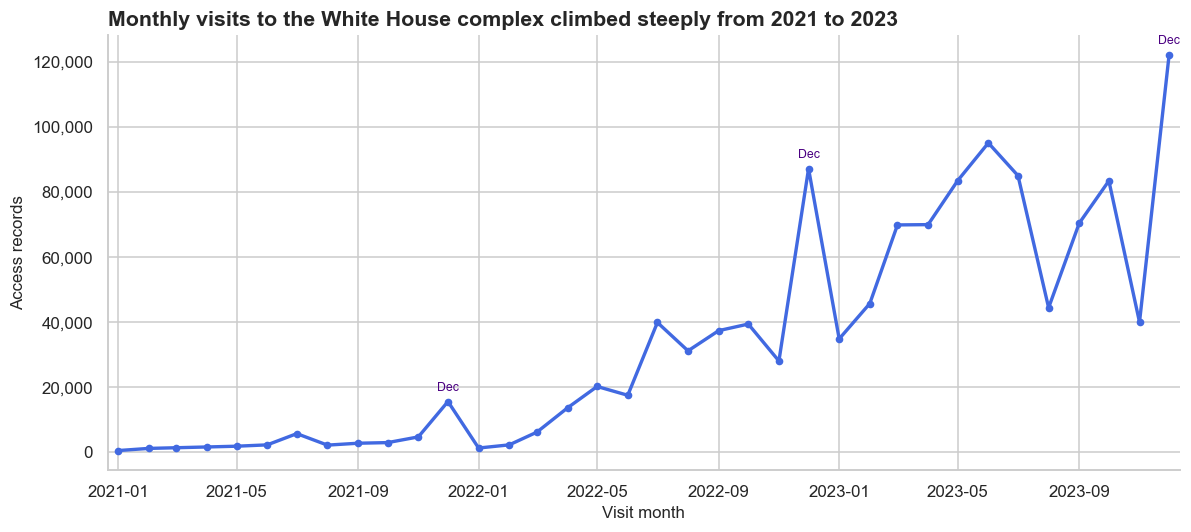

📈 Charted 36 months of visit volume, peaking at 122,138 records in December 2023


In [3]:
# Count visits per month across the full window
monthly = df.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, color=LOC_COLORS['WH'], linewidth=2.2, marker='o', markersize=4)
ax.set_title('Monthly visits to the White House complex climbed steeply from 2021 to 2023', loc='left')
ax.set_xlabel('Visit month')
ax.set_ylabel('Access records')
ax.yaxis.set_major_formatter(COMMA_FMT)
ax.margins(x=0.01)

# Flag the recurring year-end surge so the seasonal pattern is obvious
for yr in [2021, 2022, 2023]:
    dec = pd.Timestamp(f'{yr}-12-01')
    if dec in monthly.index:
        ax.annotate('Dec', xy=(dec, monthly[dec]), xytext=(0, 7),
                    textcoords='offset points', ha='center', fontsize=8, color=LOC_COLORS['VPR'])

sns.despine()
plt.tight_layout()
plt.show()

print(f'📈 Charted {len(monthly):,} months of visit volume, peaking at {monthly.max():,} records in December 2023')

### **Visual 2: Where Access Happens, and How That Shifted**

A logged visit is not one uniform thing. The complex spans the White House itself, the Eisenhower and New Executive office buildings, and the VP Residence. Early in the period, when in-person access was limited, the office buildings carried much of the traffic. As normal operations resumed, the White House proper grew to roughly four in five entries. The earliest quarters are noisier because total volume was small, so a few hundred records can swing a share.

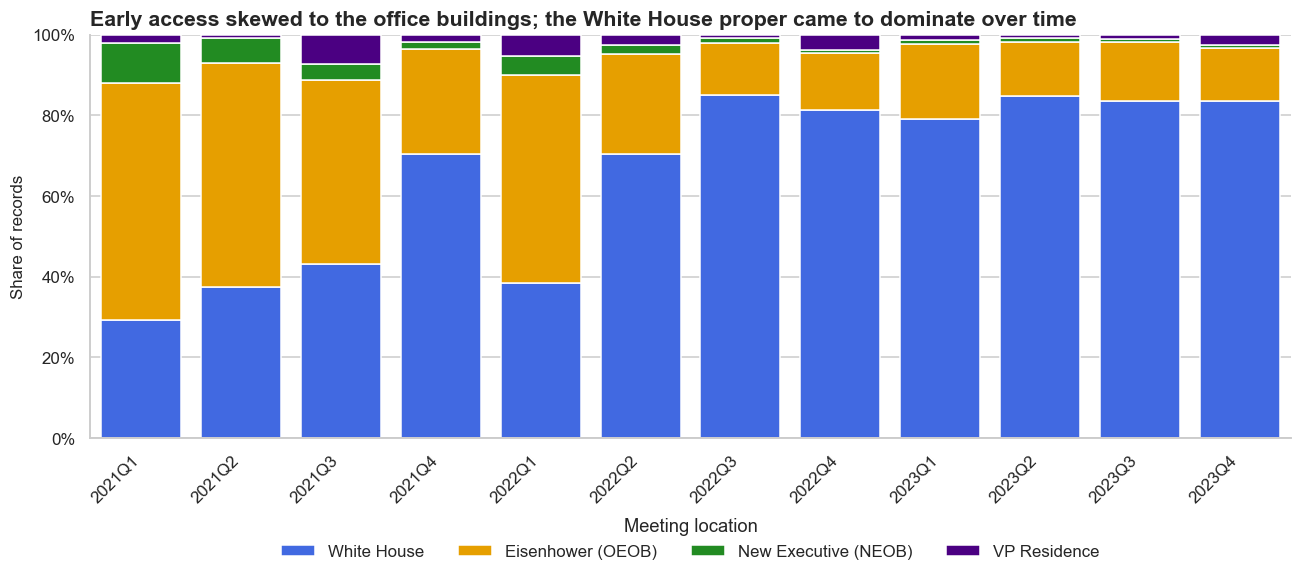

🏛️ Composition charted across 12 quarters; White House share moved from 29% to 84%


In [4]:
# Share of records by location each quarter, so composition is comparable over time
df['quarter'] = df['appt_start'].dt.to_period('Q')
piv = df.groupby(['quarter', 'meeting_loc']).size().unstack(fill_value=0)
piv = piv[[c for c in LOC_ORDER if c in piv.columns]]
share = piv.div(piv.sum(axis=1), axis=0) * 100
labels = [str(q) for q in share.index]

fig, ax = plt.subplots(figsize=(12, 5.5))

# Stack each location on top of the last, keeping the color map consistent
bottom = np.zeros(len(share))
for code in LOC_ORDER:
    ax.bar(labels, share[code].values, bottom=bottom, label=LOC_LABELS[code], color=LOC_COLORS[code], width=0.8)
    bottom += share[code].values

ax.set_title('Early access skewed to the office buildings; the White House proper came to dominate over time', loc='left')
ax.set_ylabel('Share of records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_ylim(0, 100)
ax.margins(x=0.01)
ax.legend(title='Meeting location', ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.16), frameon=False)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

print(f'🏛️ Composition charted across {len(share):,} quarters; White House share moved from {share["WH"].iloc[0]:.0f}% to {share["WH"].iloc[-1]:.0f}%')

### **Visual 3: How Far Ahead? Planning vs. Short-Notice Access**

If the logs were a record of carefully staged influence, we would expect long planning windows. Instead, access was overwhelmingly short-notice. Among visits booked on or before the visit date, most were scheduled within a week, and even the longest lead times top out near a month. The crisp line at exactly seven days suggests a scheduling convention rather than coincidence. A small share of records carry a made-date after the visit, meaning they were logged retroactively, and those are excluded here and noted.

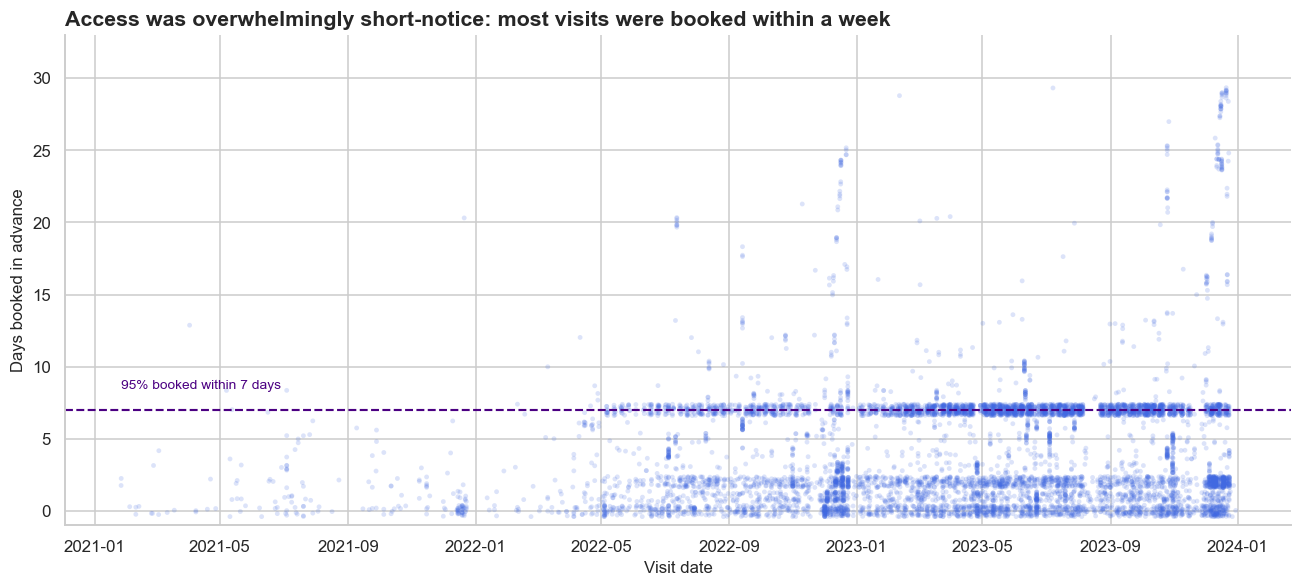

📅 Plotted 8,000 sampled visits; 95% of booked visits were scheduled within a week (excluded 18,968 records logged after the visit)


In [5]:
# Keep records booked on or before the visit, up to the observed ceiling of 32 days
booked = df[(df['lead_time_days'] >= 0) & (df['lead_time_days'] <= 32)].copy()
excluded = len(df) - len(booked)

# Sample for legibility, and jitter the integer day values so points don't stack into hard lines
sample = booked.sample(n=min(8000, len(booked)), random_state=7).copy()
jitter = np.random.default_rng(7).uniform(-0.4, 0.4, len(sample))
within_week = (booked['lead_time_days'] <= 7).mean() * 100

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.scatter(sample['appt_start'], sample['lead_time_days'] + jitter,
           s=10, alpha=0.18, color=LOC_COLORS['WH'], edgecolors='none')

# Reference line at one week to anchor the short-notice point
ax.axhline(7, color=LOC_COLORS['VPR'], linewidth=1.4, linestyle='--')
ax.annotate(f'{within_week:.0f}% booked within 7 days', xy=(sample['appt_start'].min(), 8.3),
            fontsize=9, color=LOC_COLORS['VPR'], va='bottom')

ax.set_title('Access was overwhelmingly short-notice: most visits were booked within a week', loc='left')
ax.set_xlabel('Visit date')
ax.set_ylabel('Days booked in advance')
ax.set_ylim(-1, 33)
sns.despine()
plt.tight_layout()
plt.show()

print(f'📅 Plotted {len(sample):,} sampled visits; {within_week:.0f}% of booked visits were scheduled within a week (excluded {excluded:,} records logged after the visit)')

### **Visual 4: The Scale of Access, Adding Up**

Individual months can feel abstract, so the running total makes the scale concrete. Across three years the cumulative count climbs past a million entries, and the steps grow taller as monthly volume rises. For a skeptical reader, the takeaway is the opposite of a scandal. This is the routine, high-volume throughput of a working complex, not a short list of power brokers.

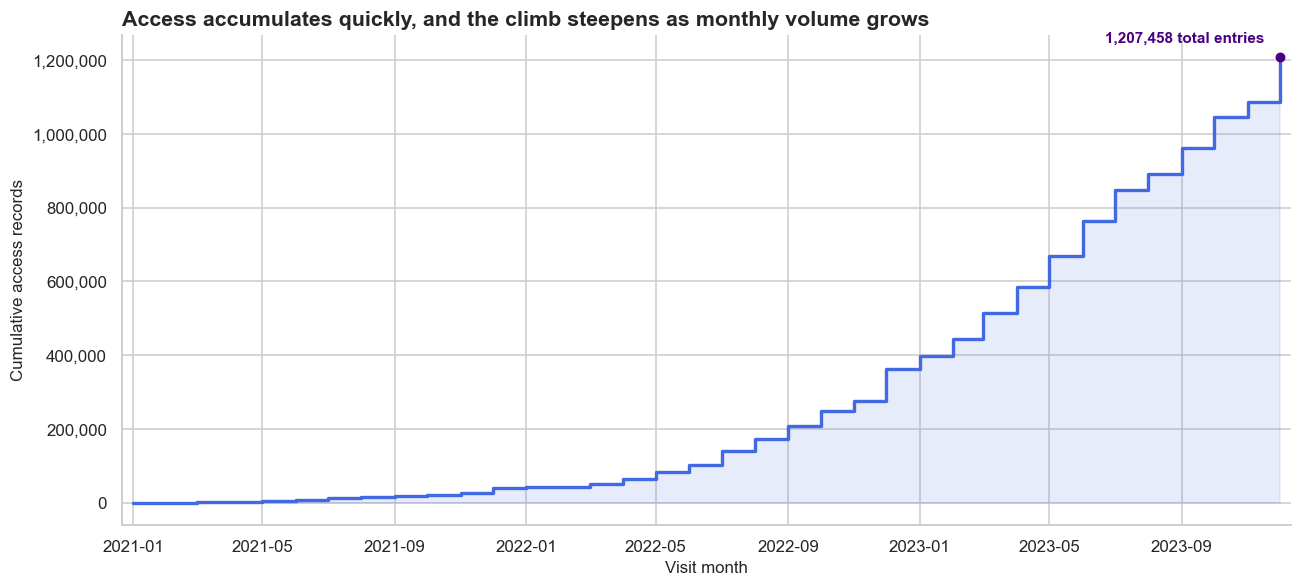

📊 Cumulative total reached 1,207,458 entries across 36 months


In [6]:
# Running total of records by month, drawn as steps so the acceleration is visible
monthly = df.groupby('year_month').size()
running_total = monthly.cumsum()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.step(running_total.index, running_total.values, where='post', color=LOC_COLORS['WH'], linewidth=2.2)
ax.fill_between(running_total.index, running_total.values, step='post', alpha=0.12, color=LOC_COLORS['WH'])

# Mark and label the final cumulative total
ax.scatter([running_total.index[-1]], [running_total.iloc[-1]], color=LOC_COLORS['VPR'], zorder=5, s=30)
ax.annotate(f'{running_total.iloc[-1]:,.0f} total entries', xy=(running_total.index[-1], running_total.iloc[-1]),
            xytext=(-10, 10), textcoords='offset points', ha='right', fontsize=10,
            color=LOC_COLORS['VPR'], fontweight='bold')

ax.set_title('Access accumulates quickly, and the climb steepens as monthly volume grows', loc='left')
ax.set_xlabel('Visit month')
ax.set_ylabel('Cumulative access records')
ax.yaxis.set_major_formatter(COMMA_FMT)
ax.margins(x=0.01)
sns.despine()
plt.tight_layout()
plt.show()

print(f'📊 Cumulative total reached {running_total.iloc[-1]:,.0f} entries across {len(running_total):,} months')

### **Visual 5: The Rhythm of the Complex**

Step away from the calendar and look at the weekly clock. Arrivals concentrate heavily in the mid-morning, and Fridays and Saturdays draw the most traffic. The Saturday peak is the tell. A large share of these "visitors" are weekend public tour-goers, not officials in meetings. This is the operational heartbeat of a building that is open to the public, and a reminder that a single record can mean a tourist as easily as a power broker.

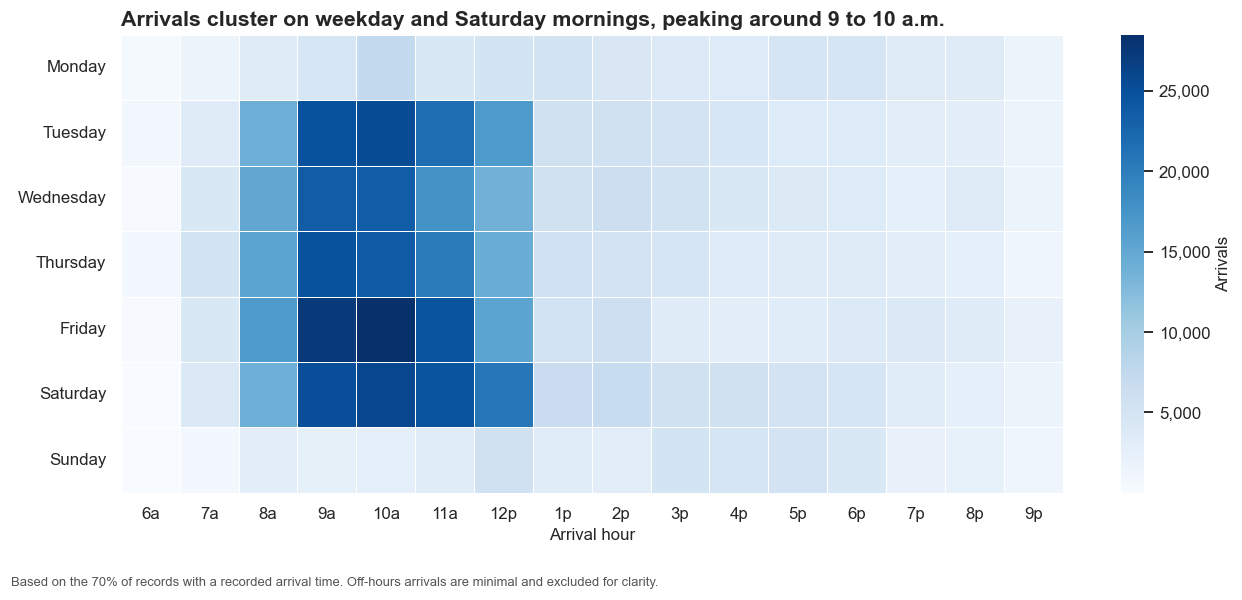

🗓️ Mapped 840,011 timed arrivals; busiest cell is Friday around 10 a.m.


In [7]:
# Weekly clock of arrivals, using only records with arrival time
WEEK_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
HOURS = list(range(6, 22))
arr = df.dropna(subset=['arrival_hour'])
arr = arr[arr['arrival_hour'].between(6, 21)]
coverage = df['arrival_hour'].notna().mean() * 100

# Build the weekday-by-hour count grid in a fixed order
grid = arr.groupby(['weekday', 'arrival_hour']).size().unstack(fill_value=0)
grid = grid.reindex(index=WEEK_ORDER, columns=HOURS, fill_value=0)
hour_labels = [f'{(h - 1) % 12 + 1}{"a" if h < 12 else "p"}' for h in HOURS]

fig, ax = plt.subplots(figsize=(12, 5.2))
sns.heatmap(grid, cmap='Blues', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Arrivals', 'format': COMMA_FMT}, ax=ax)
ax.set_title('Arrivals cluster on weekday and Saturday mornings, peaking around 9 to 10 a.m.', loc='left')
ax.set_xlabel('Arrival hour')
ax.set_ylabel('')
ax.set_xticklabels(hour_labels, rotation=0)
ax.set_yticklabels(WEEK_ORDER, rotation=0)

# Label the coverage filter right on the visual for transparency
fig.text(0.01, -0.04,
         f'Based on the {coverage:.0f}% of records with a recorded arrival time. Off-hours arrivals are minimal and excluded for clarity.',
         fontsize=8.5, color='#555555')
plt.tight_layout()
plt.show()

peak = grid.stack().idxmax()
print(f'🗓️ Mapped {len(arr):,} timed arrivals; busiest cell is {peak[0]} around {(peak[1] - 1) % 12 + 1} {"a.m." if peak[1] < 12 else "p.m."}')

### **Visual 6: Who Gets "Visited," and Why That Question Misleads**

This is where perception meets protocol. Rank the visitee field naively and you expect a leaderboard of powerful officials. Instead the field is led by the Visitors Office, the entry point for public tours, and by routing labels like POTUS and VPOTUS that tag events rather than personal meetings. Every named staff sponsor in the entire dataset, combined, still trails the tour office. The visitee field marks who sponsored or cleared an entry, not who a visitor actually met, so these logs cannot be read as a scoreboard of influence.

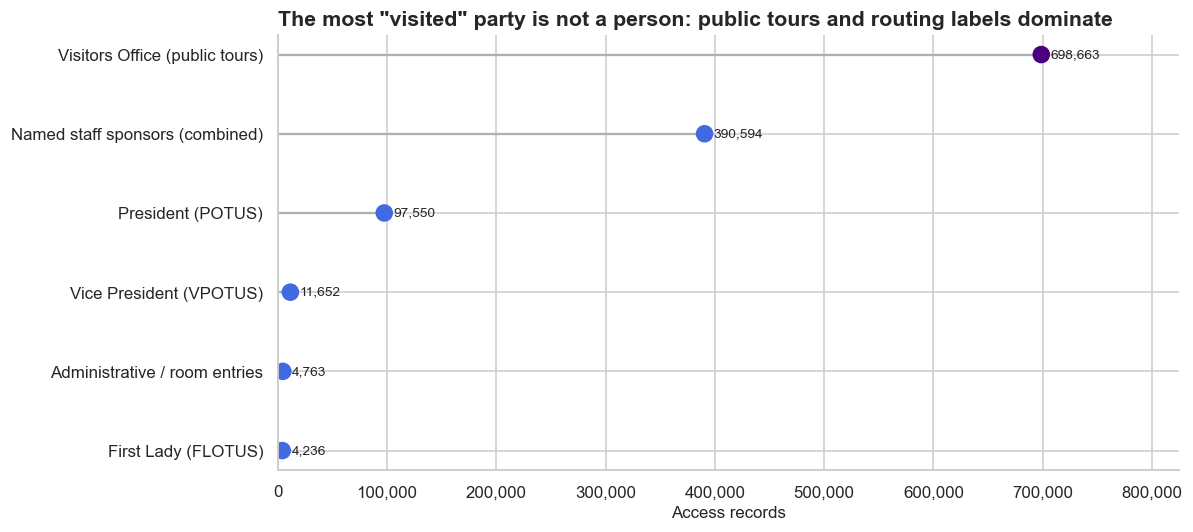

🎯 Grouped the visitee field into 6 categories; the Visitors Office alone is 58% of all records


In [8]:
# Group the visitee field so the pattern is visible without singling out any individual
ROLE = {'POTUS': 'President (POTUS)', 'VPOTUS': 'Vice President (VPOTUS)',
        'FLOTUS': 'First Lady (FLOTUS)', 'SCOTUS': 'Supreme Court (SCOTUS)'}

def bucket(v):
    if v == 'OFFICE, VISITORS':
        return 'Visitors Office (public tours)'
    if v in ROLE:
        return ROLE[v]
    if 'ROOM' in v or v == '':
        return 'Administrative / room entries'
    return 'Named staff sponsors (combined)'

df['visitee_last'] = df['visitee_last'].fillna('').str.strip().str.upper()
df['visitee_first'] = df['visitee_first'].fillna('').str.strip().str.upper()
df['visitee'] = (df['visitee_last'] + ', ' + df['visitee_first']).str.strip(', ')
df['group'] = df['visitee'].map(bucket)

counts = df['group'].value_counts()
order = counts.sort_values().index
vals = counts.loc[order].values

# Highlight the tour office to underline that the leader is not a person
colors = ['#4B0082' if g.startswith('Visitors Office') else '#4169E1' for g in order]

fig, ax = plt.subplots(figsize=(11, 5))
ax.hlines(y=range(len(order)), xmin=0, xmax=vals, color='#B0B0B0', linewidth=1.5, zorder=1)
ax.scatter(vals, range(len(order)), color=colors, s=110, zorder=2)
for i, v in enumerate(vals):
    ax.text(v + counts.max() * 0.012, i, f'{v:,.0f}', va='center', fontsize=9)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_title('The most "visited" party is not a person: public tours and routing labels dominate', loc='left')
ax.set_xlabel('Access records')
ax.xaxis.set_major_formatter(COMMA_FMT)
ax.set_xlim(0, counts.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

print(f'🎯 Grouped the visitee field into {len(counts):,} categories; the Visitors Office alone is {counts.iloc[0] / counts.sum() * 100:.0f}% of all records')

### **The Infographic Poster**

This cell composites the six visuals above into a single classroom explainer poster and exports it as PNG and PDF. The notebook is the analytical appendix; this poster is what gets presented.

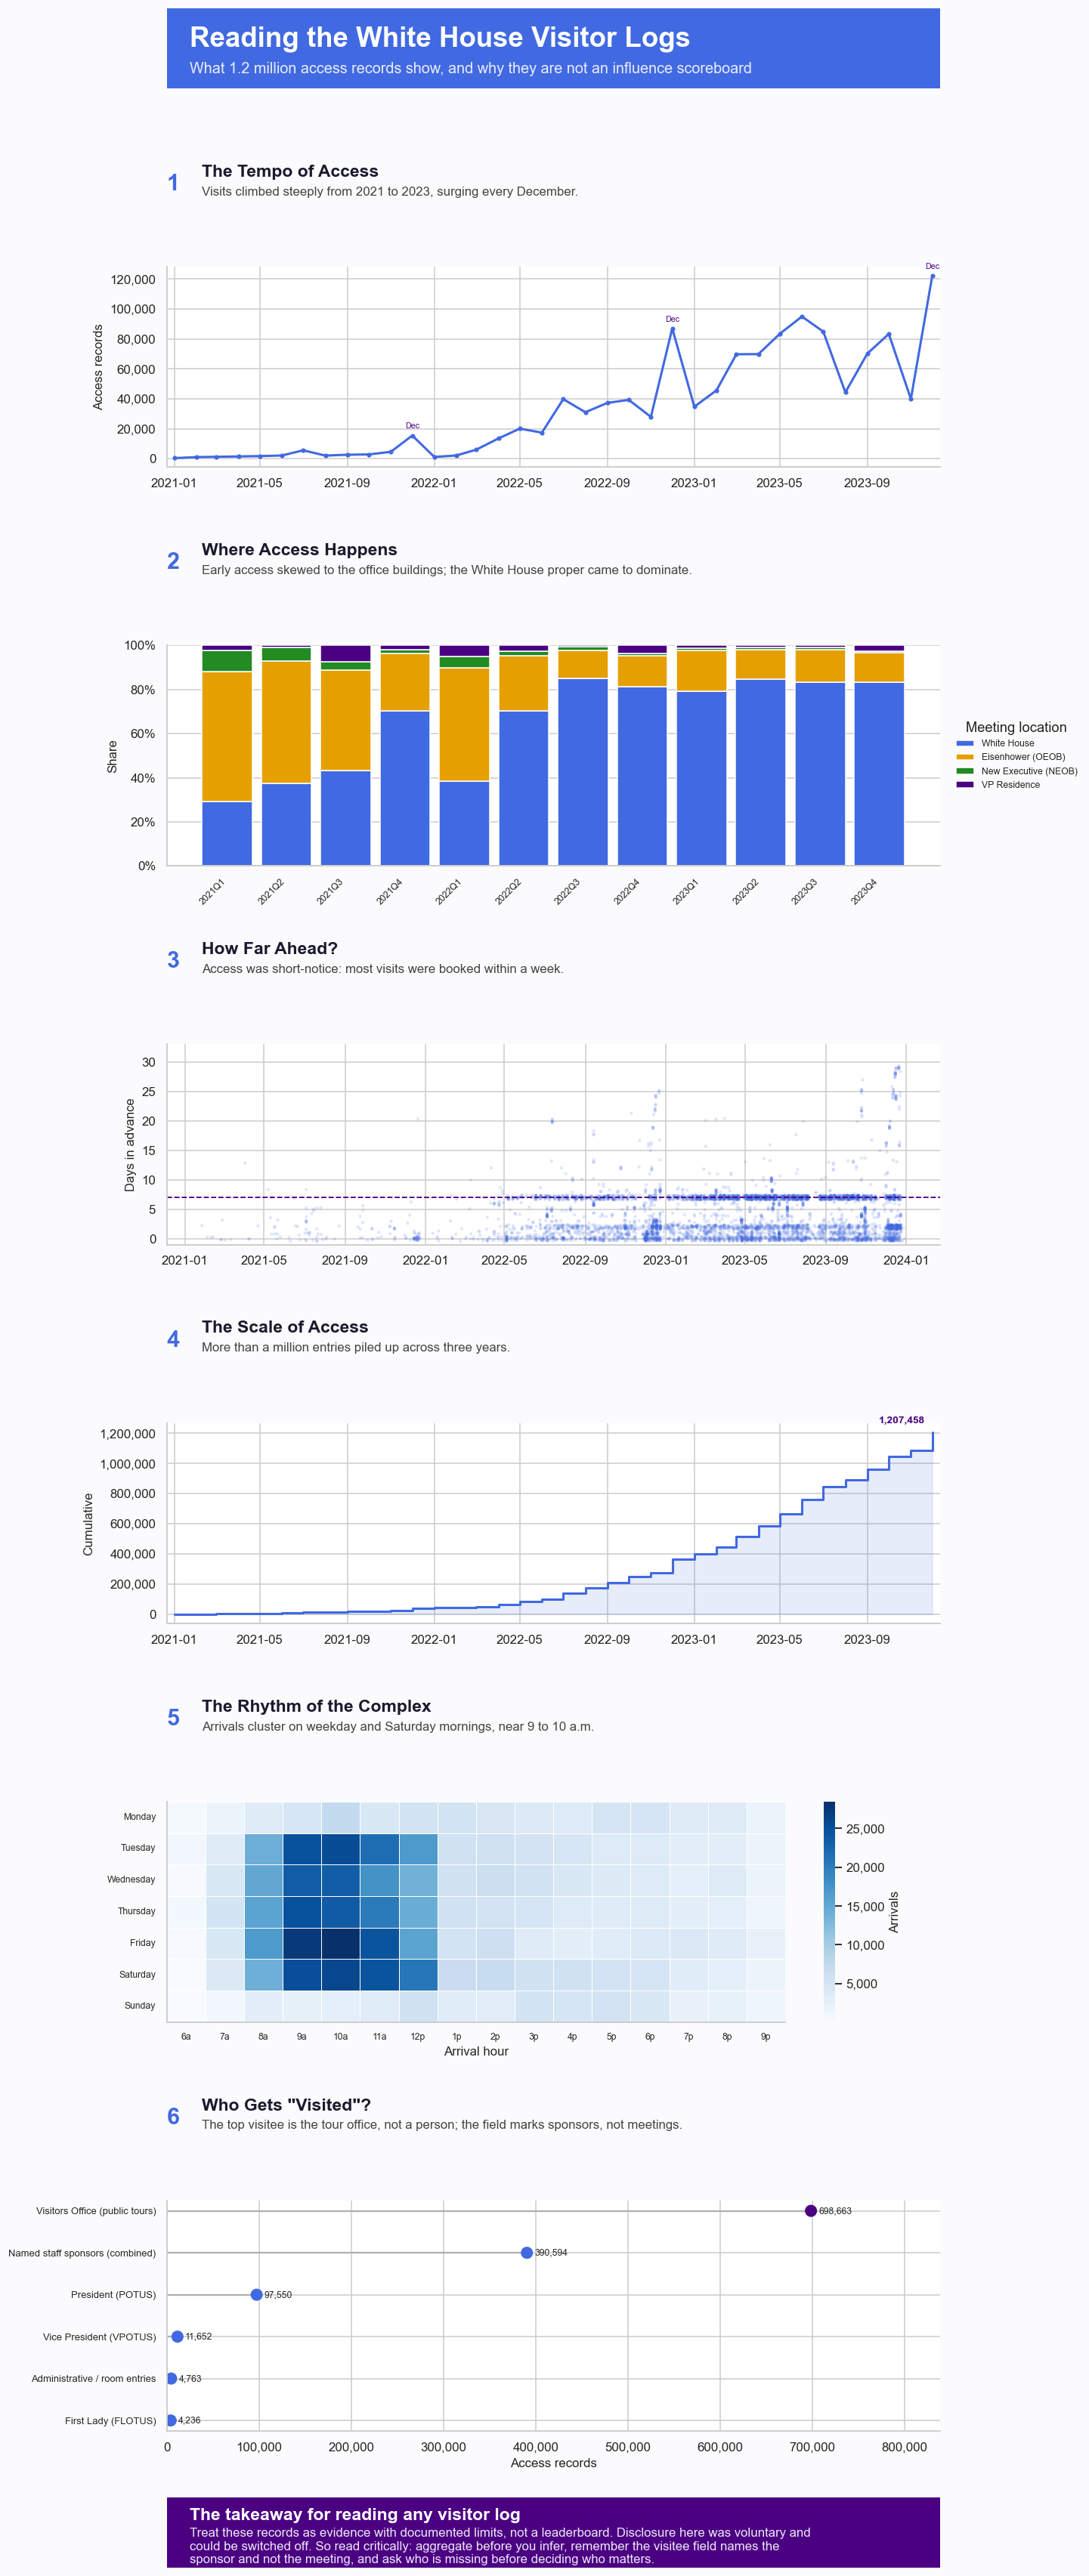

🖼️ Infographic poster exported as PNG and PDF to the notebook folder
✅ Six panels composited into one classroom explainer for 1,207,458 records


In [9]:
# Each function draws one validated visual onto a provided axis
def panel_line(ax):
    m = df.groupby('year_month').size()
    ax.plot(m.index, m.values, color=LOC_COLORS['WH'], linewidth=2, marker='o', markersize=3)
    for yr in [2021, 2022, 2023]:
        d = pd.Timestamp(f'{yr}-12-01')
        if d in m.index:
            ax.annotate('Dec', xy=(d, m[d]), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=7, color=DEEP)
    ax.set_ylabel('Access records'); ax.yaxis.set_major_formatter(COMMA_FMT); ax.margins(x=0.01)

def panel_stack(ax):
    quarter = df['appt_start'].dt.to_period('Q')
    piv = df.groupby([quarter, 'meeting_loc']).size().unstack(fill_value=0)
    piv = piv[[c for c in LOC_ORDER if c in piv.columns]]
    share = piv.div(piv.sum(axis=1), axis=0) * 100
    labels = [str(x) for x in share.index]; bottom = np.zeros(len(share))
    for code in LOC_ORDER:
        ax.bar(labels, share[code].values, bottom=bottom, label=LOC_LABELS[code], color=LOC_COLORS[code], width=0.85)
        bottom += share[code].values
    ax.set_ylabel('Share'); ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=8, title='Meeting location')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

def panel_scatter(ax):
    b = df[(df['lead_time_days'] >= 0) & (df['lead_time_days'] <= 32)]
    s = b.sample(n=min(6000, len(b)), random_state=7)
    j = np.random.default_rng(7).uniform(-0.4, 0.4, len(s))
    ax.scatter(s['appt_start'], s['lead_time_days'] + j, s=8, alpha=0.16, color=LOC_COLORS['WH'], edgecolors='none')
    ax.axhline(7, color=DEEP, linewidth=1.2, linestyle='--')
    ax.set_ylabel('Days in advance'); ax.set_ylim(-1, 33)

def panel_step(ax):
    rt = df.groupby('year_month').size().cumsum()
    ax.step(rt.index, rt.values, where='post', color=LOC_COLORS['WH'], linewidth=2)
    ax.fill_between(rt.index, rt.values, step='post', alpha=0.12, color=LOC_COLORS['WH'])
    ax.annotate(f'{rt.iloc[-1]:,.0f}', xy=(rt.index[-1], rt.iloc[-1]), xytext=(-6, 8),
                textcoords='offset points', ha='right', fontsize=9, color=DEEP, fontweight='bold')
    ax.set_ylabel('Cumulative'); ax.yaxis.set_major_formatter(COMMA_FMT); ax.margins(x=0.01)

def panel_heat(ax):
    week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']; hrs = list(range(6, 22))
    a = df.dropna(subset=['arrival_hour']); a = a[a['arrival_hour'].between(6, 21)]
    g = a.groupby(['weekday', 'arrival_hour']).size().unstack(fill_value=0).reindex(index=week, columns=hrs, fill_value=0)
    hl = [f'{(h - 1) % 12 + 1}{"a" if h < 12 else "p"}' for h in hrs]
    sns.heatmap(g, cmap='Blues', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Arrivals', 'format': COMMA_FMT}, ax=ax)
    ax.set_xticklabels(hl, rotation=0, fontsize=8); ax.set_yticklabels(week, rotation=0, fontsize=8)
    ax.set_ylabel(''); ax.set_xlabel('Arrival hour')

def panel_lolli(ax):
    role = {'POTUS': 'President (POTUS)', 'VPOTUS': 'Vice President (VPOTUS)', 'FLOTUS': 'First Lady (FLOTUS)', 'SCOTUS': 'Supreme Court (SCOTUS)'}
    def bucket(v):
        if v == 'OFFICE, VISITORS': return 'Visitors Office (public tours)'
        if v in role: return role[v]
        if 'ROOM' in v or v == '': return 'Administrative / room entries'
        return 'Named staff sponsors (combined)'
    vl = df['visitee_last'].fillna('').str.strip().str.upper(); vf = df['visitee_first'].fillna('').str.strip().str.upper()
    grp = (vl + ', ' + vf).str.strip(', ').map(bucket); counts = grp.value_counts()
    order = counts.sort_values().index; vals = counts.loc[order].values
    colors = [DEEP if g.startswith('Visitors Office') else LOC_COLORS['WH'] for g in order]
    ax.hlines(y=range(len(order)), xmin=0, xmax=vals, color='#B0B0B0', linewidth=1.5)
    ax.scatter(vals, range(len(order)), color=colors, s=90, zorder=2)
    for i, val in enumerate(vals):
        ax.text(val + counts.max() * 0.012, i, f'{val:,.0f}', va='center', fontsize=8)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8.5)
    ax.set_xlabel('Access records'); ax.xaxis.set_major_formatter(COMMA_FMT); ax.set_xlim(0, counts.max() * 1.2)

# Section number, name, takeaway, and drawing function for each panel
PANELS = [
    ('1', 'The Tempo of Access', 'Visits climbed steeply from 2021 to 2023, surging every December.', panel_line),
    ('2', 'Where Access Happens', 'Early access skewed to the office buildings; the White House proper came to dominate.', panel_stack),
    ('3', 'How Far Ahead?', 'Access was short-notice: most visits were booked within a week.', panel_scatter),
    ('4', 'The Scale of Access', 'More than a million entries piled up across three years.', panel_step),
    ('5', 'The Rhythm of the Complex', 'Arrivals cluster on weekday and Saturday mornings, near 9 to 10 a.m.', panel_heat),
    ('6', 'Who Gets "Visited"?', 'The top visitee is the tour office, not a person; the field marks sponsors, not meetings.', panel_lolli),
]

# Tall portrait canvas: banner, then heading + chart per panel, then a call-to-action footer
fig = plt.figure(figsize=(12, 40)); fig.patch.set_facecolor('#FBFBFD')
gs = fig.add_gridspec(nrows=14, ncols=1,
                      height_ratios=[1.6, 0.9, 4, 0.9, 4.4, 0.9, 4, 0.9, 4, 0.9, 4.4, 0.9, 4.6, 1.4], hspace=0.55)

tb = fig.add_subplot(gs[0]); tb.axis('off')
tb.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle='round,pad=0.02,rounding_size=0.03', transform=tb.transAxes, facecolor=ACCENT, edgecolor='none'))
tb.text(0.03, 0.62, 'Reading the White House Visitor Logs', transform=tb.transAxes, fontsize=24, fontweight='bold', color='white', va='center')
tb.text(0.03, 0.24, 'What 1.2 million access records show, and why they are not an influence scoreboard', transform=tb.transAxes, fontsize=13, color='#E8ECFF', va='center')

for (num, name, take, fn), row in zip(PANELS, [2, 4, 6, 8, 10, 12]):
    h = fig.add_subplot(gs[row - 1]); h.axis('off')
    h.text(0.0, 0.35, num, transform=h.transAxes, fontsize=20, fontweight='bold', color=ACCENT, va='center')
    h.text(0.045, 0.62, name, transform=h.transAxes, fontsize=15, fontweight='bold', color=INK, va='center')
    h.text(0.045, 0.18, take, transform=h.transAxes, fontsize=11, color='#444444', va='center')
    ax = fig.add_subplot(gs[row]); fn(ax); sns.despine(ax=ax)

ft = fig.add_subplot(gs[13]); ft.axis('off')
ft.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle='round,pad=0.02,rounding_size=0.04', transform=ft.transAxes, facecolor=DEEP, edgecolor='none'))
ft.text(0.03, 0.74, 'The takeaway for reading any visitor log', transform=ft.transAxes, fontsize=15, fontweight='bold', color='white', va='center')
cta = ('Treat these records as evidence with documented limits, not a leaderboard. Disclosure here was voluntary and\n'
       'could be switched off. So read critically: aggregate before you infer, remember the visitee field names the\n'
       'sponsor and not the meeting, and ask who is missing before deciding who matters.')
ft.text(0.03, 0.30, cta, transform=ft.transAxes, fontsize=11, color='#EDE7F6', va='center')

fig.savefig('white_house_logs_infographic.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
fig.savefig('white_house_logs_infographic.pdf', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('🖼️ Infographic poster exported as PNG and PDF to the notebook folder')
print(f'✅ Six panels composited into one classroom explainer for {len(df):,} records')

<div style="page-break-before: always;"></div>

<h2 style="margin-top:0.5in;">Reading the White House Visitor Logs: A Visual Story for Political Science Students</h2> 

<div style="line-height: 2;">

**Audience**

<p style="text-indent: 0.5in; margin: 0;">I built this story for an undergraduate political science class studying transparency and access in the executive branch. They are sharp and curious, but I did not assume they already know how the visitor log system works, so I explained what the WAVES records actually capture before drawing any conclusions. My focus throughout was on how these records get read, and misread.</p>

**Purpose**

<p style="text-indent: 0.5in; margin: 0;">My purpose was to correct a perception rather than simply inform. Visitor logs are often treated as an influence scoreboard, a ranking of who has the President's ear. I used the six visuals together to show why that reading falls apart, moving from raw tempo and scale toward the specific fields that get misinterpreted. I stated the call to action plainly in the closing footer: treat these logs as evidence with documented limits, not a leaderboard.</p>

**Medium**

<p style="text-indent: 0.5in; margin: 0;">I chose a single infographic poster built entirely in Python, which fits a classroom audience because it can be read top to bottom in one pass, and building it in matplotlib kept every visual native to the analysis instead of pasted in from somewhere else.</p>

**Design**

<p style="text-indent: 0.5in; margin: 0;">I ran one colorblind-safe palette through every chart and locked each meeting location to a single color, so the legend only has to be learned once. I wrote each title as a plain-language takeaway, formatted numbers with commas instead of scientific notation, and never truncated an axis to exaggerate a gap. I ordered the panels to match the argument, moving from tempo, to scale, to the fields that mislead.</p>

**Ethical Considerations**

<p style="text-indent: 0.5in; margin: 0;">All of the records come from the White House's own voluntary disclosure, so the data is first-party and was released rather than scraped (The White House, n.d.). I disclosed my cleaning instead of hiding it. I reconciled two different header schemas, merged EEOB into OEOB as the same building, parsed mixed date formats, and dropped rows with no usable visit date after counting them. I grouped the visitee field rather than ranking people by name, so no private individual is singled out, which is also the central lesson, since that field records the sponsor who cleared an entry and not who a visitor actually met. The biggest risks here are interpretive. Arrival-time coverage is only about 70 percent, the logs capture only this complex and miss meetings held elsewhere, and disclosure was voluntary and has since stopped. I tried to mitigate these by labeling every filter, reporting coverage on the chart itself, and aggregating before I inferred anything.</p>

</div>


# Reflection 

## General Reflection
This week’s assignment pushed me to think about data storytelling in a more nuanced way, especially when working with a politically sensitive dataset like the White House Visitor Logs. Even though the exercise wasn’t political, the data itself carries a lot of public perception baggage, so shaping the narrative responsibly mattered. What stood out most was how different the story becomes once the visuals are aggregated and contextualized. Instead of implying influence or access, the data revealed operational rhythms, seasonal patterns, and the sheer scale of public-facing activity.

Building the infographic helped me organize the narrative into a top‑to‑bottom argument: start with tempo, move into composition, highlight planning behavior, show cumulative scale, then shift into operational patterns and finally the misinterpretation of the visitee field. The poster format made it easier to guide the audience through the story while keeping the call to action clear — these logs should be read critically, not as a leaderboard.

## Straightforward Aspects
- Loading and consolidating the 25 monthly datasets was smooth thanks to consistent preprocessing steps. Renaming headers, merging EEOB/OEOB, and parsing mixed date formats were all manageable.
- The required chart types aligned well with the dataset. The line chart, stacked bar, scatterplot with time, and step chart each mapped naturally to the story I wanted to tell.
- Identifying the audience (political science undergraduates) made design choices easier. Clear labeling, color consistency, and plain‑language takeaways fit their level of familiarity.
- The narrative emerged organically from the visuals. For example, the December surges, the dominance of public tours, and the short-notice scheduling were immediately visible once plotted.

## Challenging Aspects
- Ethical considerations required careful attention. The logs contain sponsor names, so grouping visitees into categories was necessary to avoid implying personal influence or singling out individuals.
- Arrival-time coverage was only about 70%, which meant I needed to label filters directly on the visual to avoid misleading interpretations.
- The visitee field itself is inherently confusing — it records who cleared an entry, not who was met. Communicating that clearly without overexplaining took some refinement.
- Designing a single infographic with six distinct visuals required balancing spacing, alignment, and visual hierarchy so the poster didn’t feel cluttered.
- Ensuring the call to action remained visible and meaningful was a challenge. I had to reinforce throughout the visuals that visitor logs have limits, gaps, and interpretive risks.

